In [1]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",
    #message = ".*Warning.*",
    category=UserWarning,
    module="transformers.modeling_utils"  
)

load_dotenv()

True

## Fetch results

In [3]:
ds = Dataset("test")
cm = CollectMetrics()
eval_res = ds.load_evaluation_results()
all_eval_runs = cm.organize_runs_by_type(eval_res)

In [4]:
coll_res = ds.load_results()
all_collected_res = cm.organize_runs_by_type(coll_res)

In [5]:
deepeval_obs = []
for runs in all_eval_runs.values():
    deepeval_obs.extend(cm.collect_deepeval_metrics(runs))

deepeval_obs[:2], len(deepeval_obs)

([DeepEvalObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name='Turn unknown in session Prosjekt-initialisering', correctness=0.7, relevancy=0.7, completeness=0.9, success=True),
  DeepEvalObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name='Turn 1 in session Prosjekt-initialisering', correctness=0.8, relevancy=1.0, completeness=0.7, success=True)],
 59)

In [6]:
berts = []
for runs in all_eval_runs.values():
    berts.extend(cm.collect_berts(runs))

berts[:2], len(berts)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

([ReferenceObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name=None, bert_precision=0.5848439335823059, bert_recall=0.690008819103241, bert_f1=0.6330887675285339, s_bert_similarity=0.9543586059131249),
  ReferenceObservation(dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom', name=None, bert_precision=0.6300543546676636, bert_recall=0.7086403965950012, bert_f1=0.6670407056808472, s_bert_similarity=0.9181707722712509)],
 59)

In [7]:
gathered_res = ds.load_results()
resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

resource_obs[:2], len(resource_obs)

([ResourceObservation(starttime=datetime.datetime(2026, 3, 7, 18, 47, 34, 992180), endtime=datetime.datetime(2026, 3, 7, 18, 47, 45, 760740), duration_seconds=10.76856, input_tokens=9943, output_tokens=1566, total_tokens=11509, llm_calls=1, dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='f3f226bb-eb5c-4b87-8d96-dfa425614f42', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model='google_gemini-2.5-flash', agent_type='custom'),
  ResourceObservation(starttime=datetime.datetime(2026, 3, 7, 18, 47, 45, 760950), endtime=datetime.datetime(2026, 3, 7, 18, 48, 5, 684568), duration_seconds=19.923618, input_tokens=27706, output_tokens=2993, total_tokens=30699, llm_calls=2, dataset_name='test', eval_run_id='3ef71ca0-1294-4e01-932f-5ab8b7b53a73', query_id='070f570b-f9d0-454f-90ca-84f66ede1a31', session_id='0b784eaf-8d41-4990-84c9-1d50f34de5fa', session=0, session_name='Prosjekt-initialisering', llm_model=

## EDA
### Exploratory data analysis

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import subplots
import pandas as pd

In [9]:
df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
drop = ["eval_run_id", 
        "name",
        #"query_id", "session_id", 
        ]
on = ["llm_model", "dataset_name", 
        "query_id", "session_id", "agent_type",
        "session", "session_name"]

df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
                                                                                                              
df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)

In [10]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,correctness,relevancy,completeness,...,endtime,duration_seconds,input_tokens,output_tokens,total_tokens,llm_calls,bert_precision,bert_recall,bert_f1,s_bert_similarity
0,test,f3f226bb-eb5c-4b87-8d96-dfa425614f42,0b784eaf-8d41-4990-84c9-1d50f34de5fa,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,0.7,0.7,0.9,...,2026-03-07 18:47:45.760740,10.768560,9943,1566,11509,1,0.584844,0.690009,0.633089,0.954359
1,test,070f570b-f9d0-454f-90ca-84f66ede1a31,0b784eaf-8d41-4990-84c9-1d50f34de5fa,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,0.8,1.0,0.7,...,2026-03-07 18:48:05.684568,19.923618,27706,2993,30699,2,0.630054,0.708640,0.667041,0.918171
2,test,e17e38f3-0c98-4fbf-bb93-a30742d8efc2,9c4e5a04-8c02-4e1f-b178-02b3e46e8ecd,1,Stevning og tilsvar,google_gemini-2.5-flash,custom,0.5,0.4,0.4,...,2026-03-07 18:50:54.397872,5.384846,17284,807,18091,1,0.619952,0.675889,0.646713,0.880004
3,test,c064ef16-3081-44f8-8444-b0df672ec840,9c4e5a04-8c02-4e1f-b178-02b3e46e8ecd,1,Stevning og tilsvar,google_gemini-2.5-flash,custom,0.6,1.0,0.8,...,2026-03-07 18:50:49.012785,13.205039,30683,1813,32496,2,0.686709,0.724534,0.705115,0.922206
4,test,f3f226bb-eb5c-4b87-8d96-dfa425614f42,4cdeb92e-0849-42e8-bed3-44b4ae13e36a,0,Prosjekt-initialisering,google_gemini-2.5-flash,custom,1.0,0.8,1.0,...,2026-03-07 17:37:15.205409,9.038186,9439,1158,10597,1,0.638840,0.679709,0.658641,0.946664


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dataset_name       59 non-null     object        
 1   query_id           59 non-null     object        
 2   session_id         59 non-null     object        
 3   session            59 non-null     int64         
 4   session_name       59 non-null     object        
 5   llm_model          59 non-null     object        
 6   agent_type         59 non-null     object        
 7   correctness        59 non-null     float64       
 8   relevancy          59 non-null     float64       
 9   completeness       59 non-null     float64       
 10  success            59 non-null     bool          
 11  starttime          59 non-null     datetime64[ns]
 12  endtime            59 non-null     datetime64[ns]
 13  duration_seconds   59 non-null     float64       
 14  input_tokens

In [12]:
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"
df.loc[df["llm_model"] == "zai_zai-org/GLM-5" , "llm_model"] = "GLM-5"
df.loc[df["llm_model"] == "google_gemini-2.5-flash" , "llm_model"] = "gemini-2.5-flash"

models_to_keep = ["Qwen3.5-397B-A17B", "GLM-5", "gemini-2.5-flash"]
df = df[df["llm_model"].isin(models_to_keep)]
df["llm_model"].value_counts()

llm_model
Qwen3.5-397B-A17B    16
GLM-5                11
gemini-2.5-flash      8
Name: count, dtype: int64

### Deep Eval metrics
Correctness, relevancy & completeness

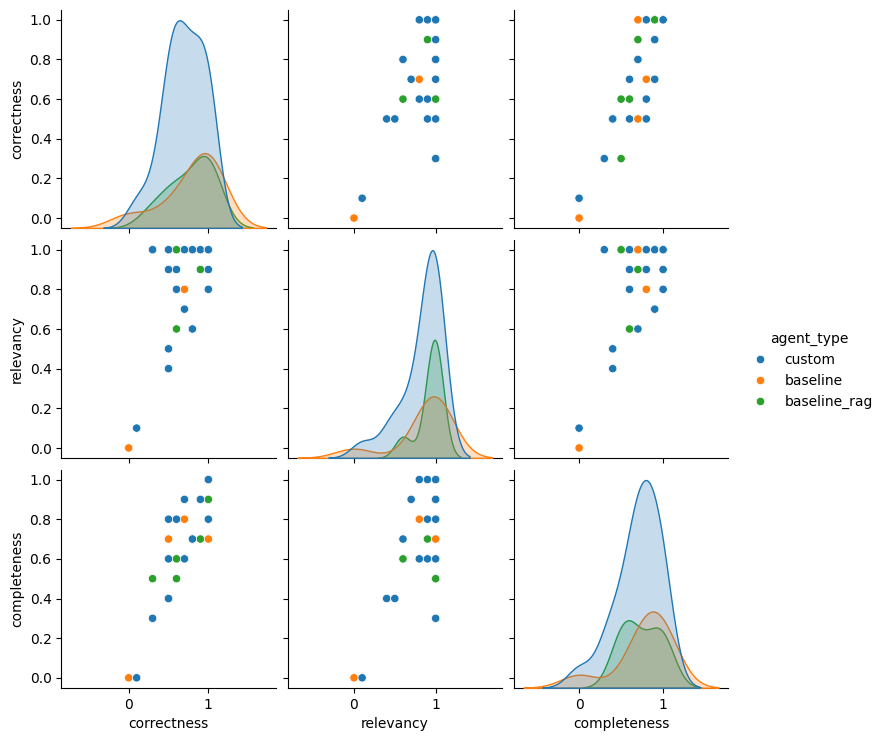

In [13]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], hue = "agent_type")

<Axes: xlabel='success', ylabel='Count'>

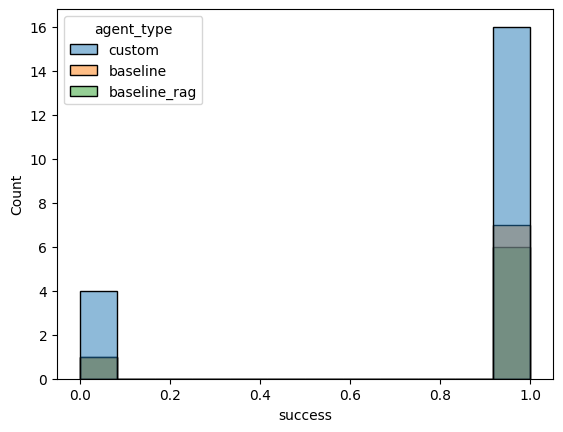

In [14]:
sns.histplot(df, x = "success", hue = "agent_type")

### Bert metrics
S-bert & Bert score

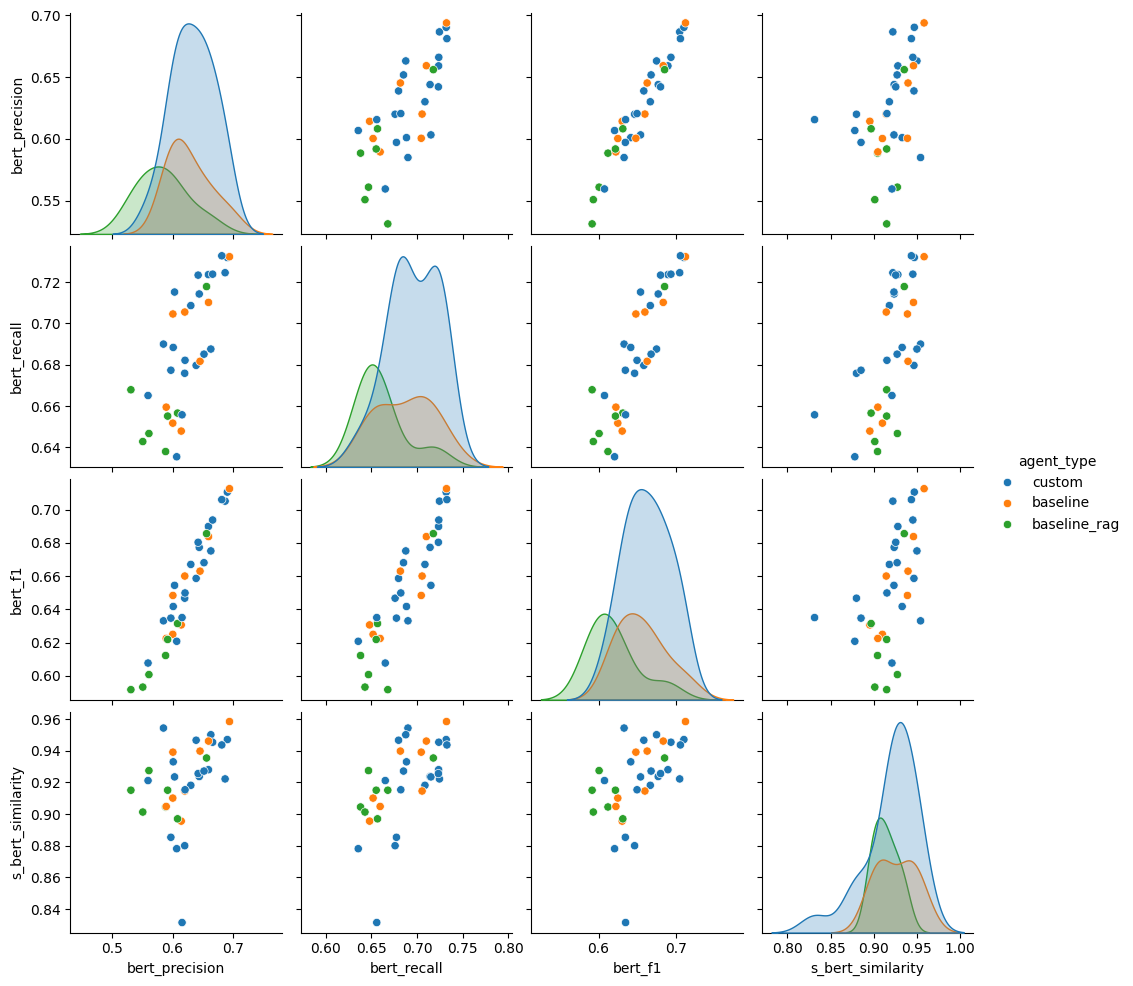

In [15]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], hue = "agent_type")

### Resource metrics
Token & time usage

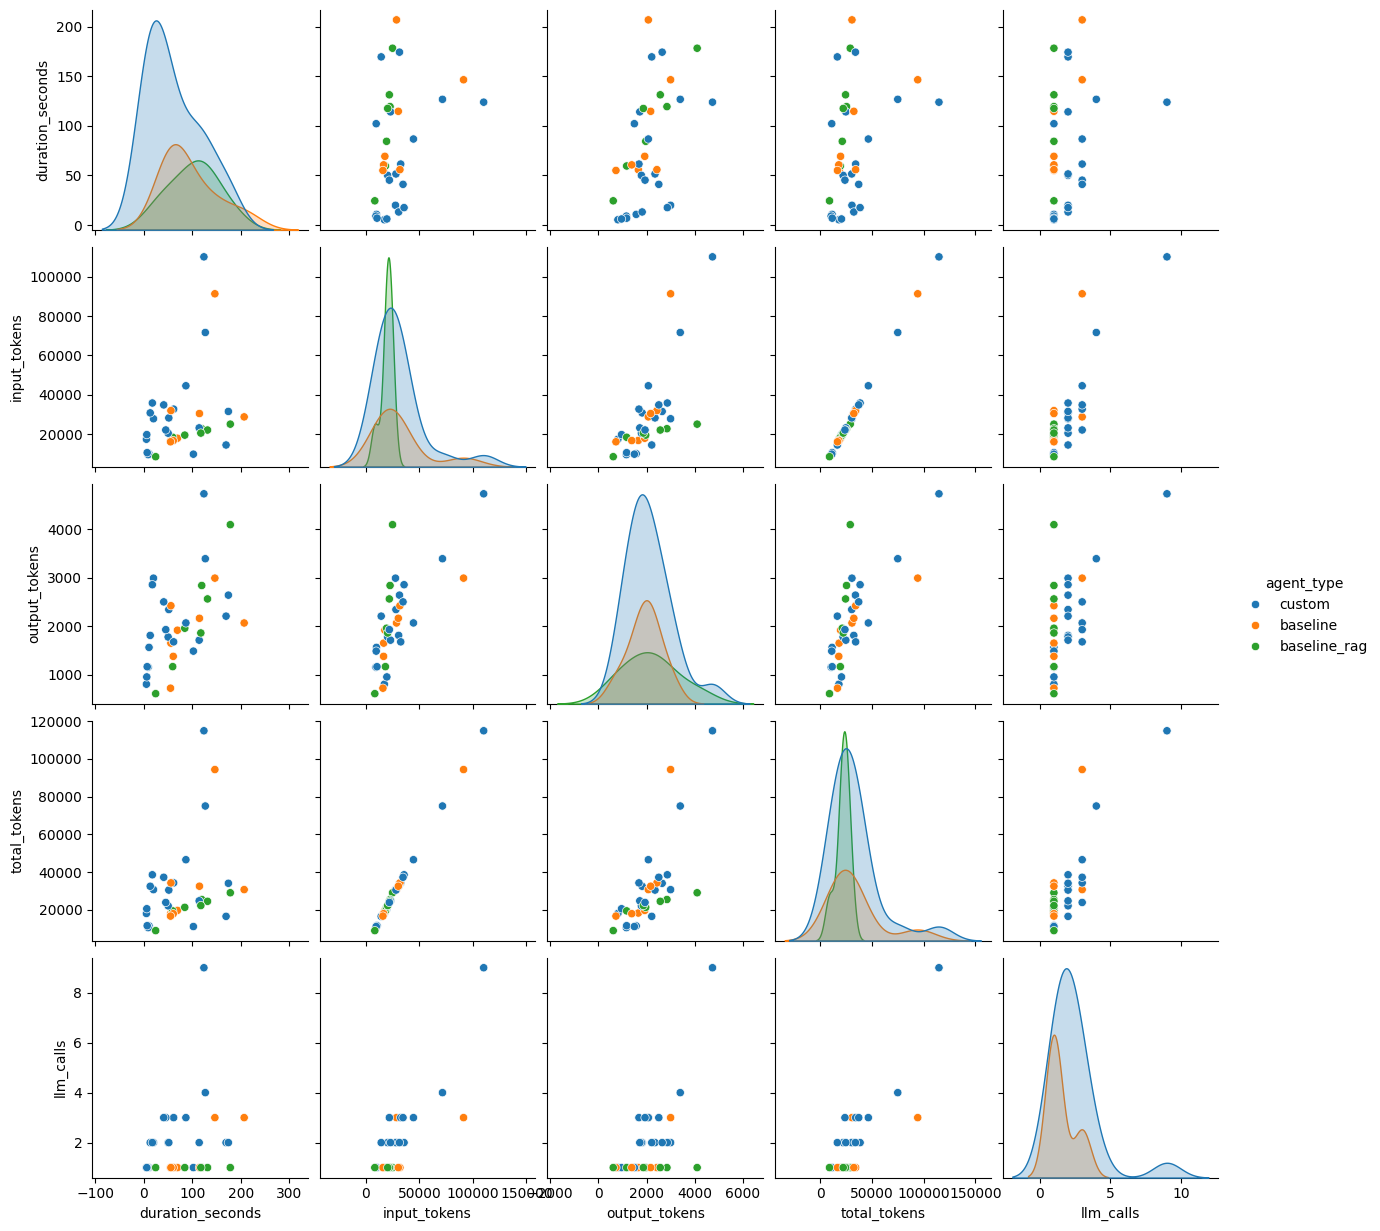

In [16]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], hue = "agent_type")

### Combined analysis

<Axes: xlabel='duration_seconds', ylabel='correctness'>

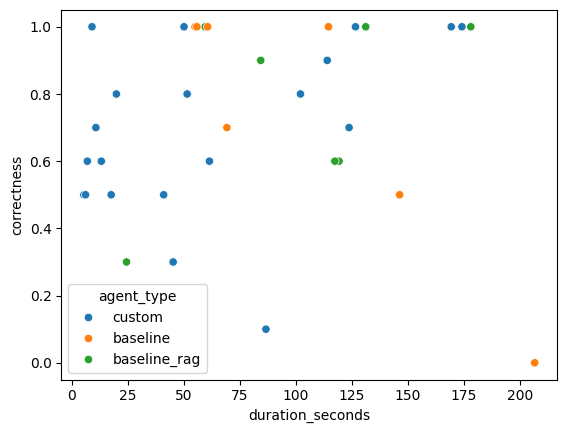

In [17]:
import seaborn as sns

sns.scatterplot(df, x = "duration_seconds", y = "correctness", hue = "agent_type")

In [18]:
dfg = df.groupby(by = ["agent_type", "llm_model"],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

In [19]:
dfg

correctness  relevancy  completeness  \
agent_type   llm_model                                                 
baseline     GLM-5                 1.000000     1.0000      0.925000   
             Qwen3.5-397B-A17B     0.550000     0.7000      0.600000   
baseline_rag GLM-5                 0.633333     1.0000      0.666667   
             Qwen3.5-397B-A17B     0.875000     0.8750      0.800000   
custom       GLM-5                 0.625000     1.0000      0.675000   
             Qwen3.5-397B-A17B     0.775000     0.8125      0.737500   
             gemini-2.5-flash      0.650000     0.7625      0.675000   

                                 bert_f1  duration_seconds  total_tokens  
agent_type   llm_model                                                    
baseline     GLM-5              0.654403         71.545373     25369.000  
             Qwen3.5-397B-A17B  0.657062        119.539563     40757.500  
baseline_rag GLM-5              0.646299         91.058717     18604.000  
             Qwen3.5-397B-A17B  0.599463        110.362954     23832.750  
custom       GLM-5              0.664755         84.205698     62739.750  
             Qwen3.5-397B-A17B  0.662420        101.209426     27503.375  
             gemini-2.5-flash   0.662199         11.128313     21772.625

In [20]:
dfs = df.groupby(by = ["agent_type", "llm_model", "session",],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "total_tokens" : "mean"})

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

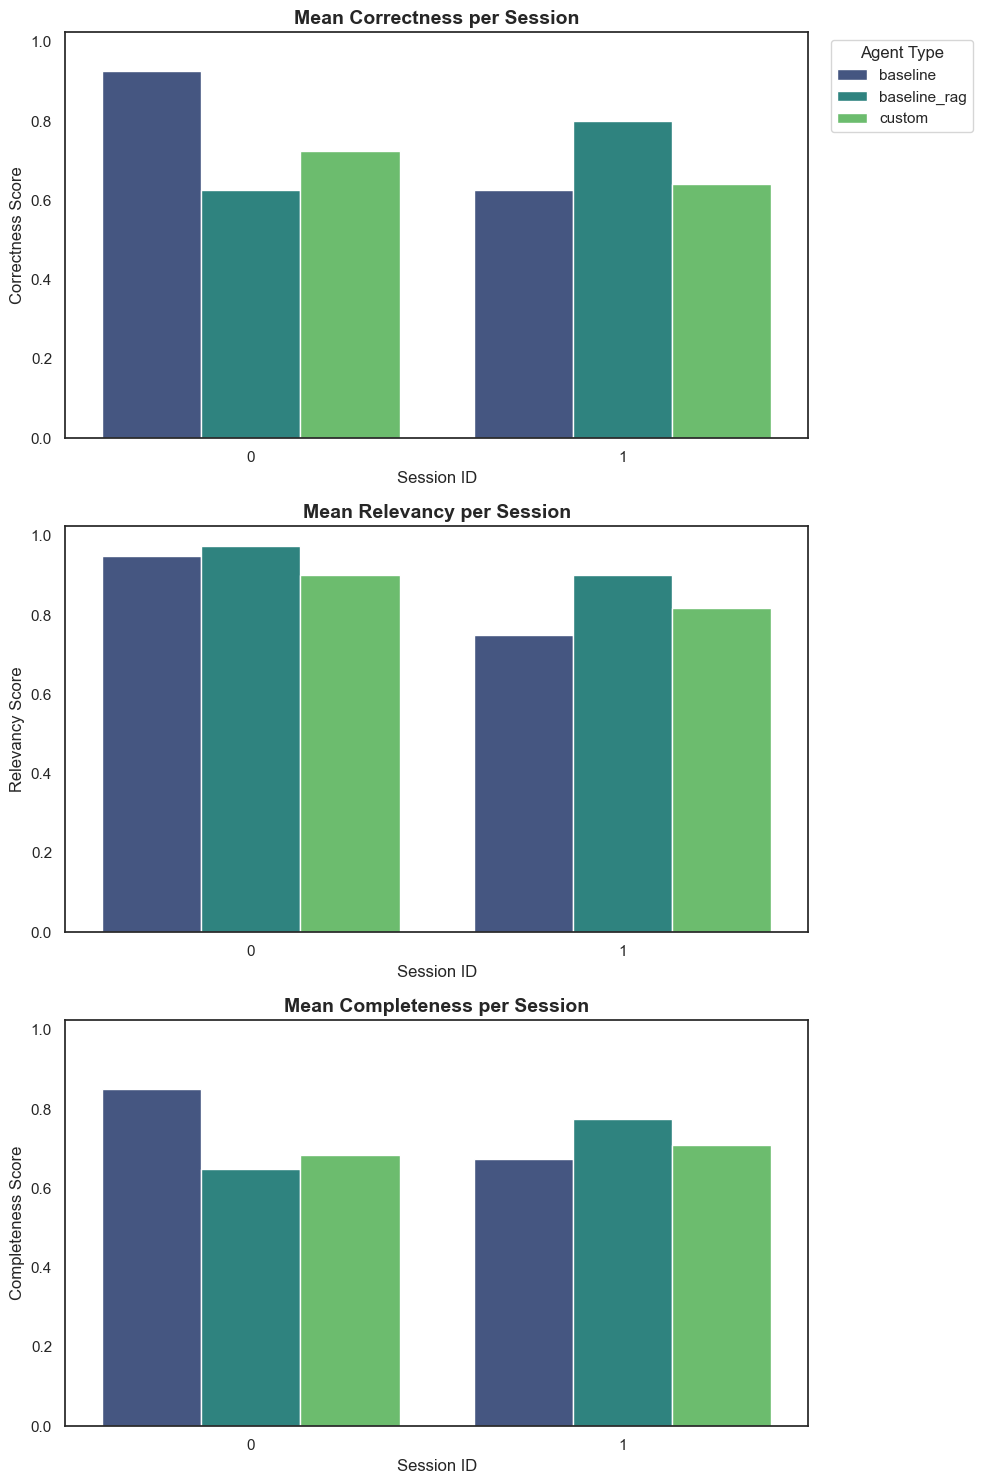

''

In [29]:
sns.set_theme(style="white")
metrics = ["correctness", "relevancy", "completeness"]

fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 15), sharey=True)

for i, metric in enumerate(metrics):
    sns.barplot(
        data=dfs,
        x="session",
        y=metric,
        hue="agent_type",
        ax=axes[i],
        palette="viridis",
        errorbar=None
    )
    
    axes[i].set_title(f"Mean {metric.capitalize()} per Session", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Session ID", fontsize=12)
    axes[i].set_ylabel(f"{metric.capitalize()} Score", fontsize=12)
    
    if i != 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Agent Type", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()
;

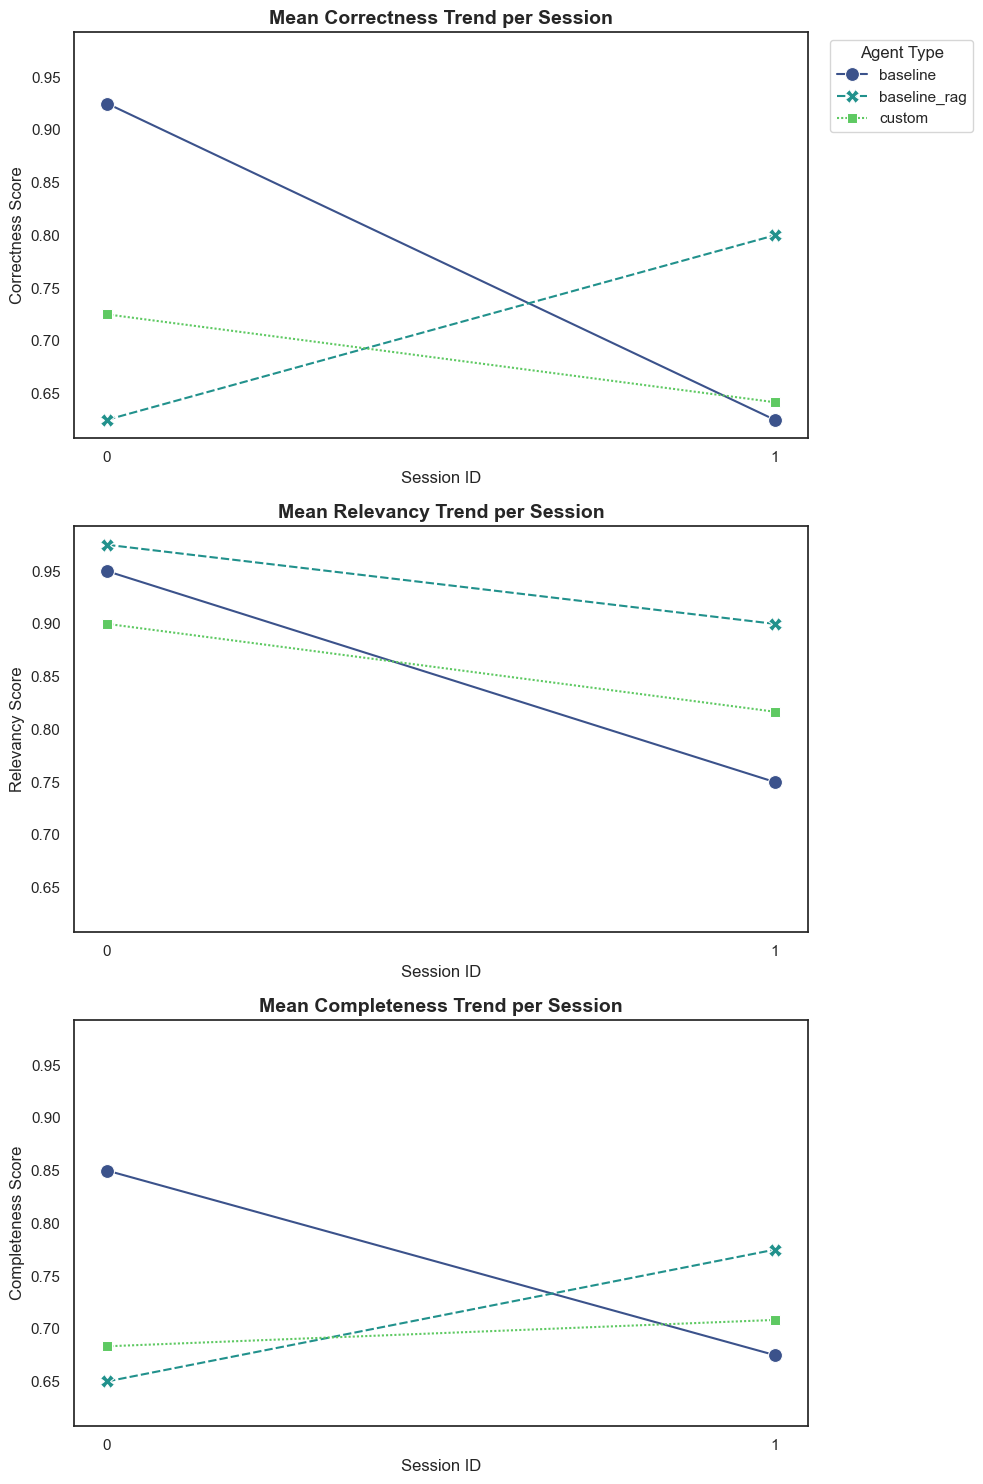

''

In [30]:
sns.set_theme(style="white")
metrics = ["correctness", "relevancy", "completeness"]

fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(10, 15), sharey=True)

plot_df = dfs.reset_index().sort_values("session")

for i, metric in enumerate(metrics):
    sns.lineplot(
        data=plot_df,
        x="session",
        y=metric,
        hue="agent_type",
        style="agent_type", 
        markers=True,        
        markersize=10,
        ax=axes[i],
        palette="viridis",
        errorbar=None
    )
    
    axes[i].set_title(f"Mean {metric.capitalize()} Trend per Session", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Session ID", fontsize=12)
    axes[i].set_ylabel(f"{metric.capitalize()} Score", fontsize=12)
    
    axes[i].set_xticks(plot_df['session'].unique())
    
    if i != 0:
        legend = axes[i].get_legend()
        if legend: legend.remove()
    else:
        axes[i].legend(title="Agent Type", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()
;

## Statistical Modeling

In [42]:
import numpy as np
from scipy import stats 

from evals.models import DeepEvalObservation

In [43]:
class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values : list[float]):
            result = stats.shapiro(values)
            status = "✅" if result.pvalue > self.significance_level else "❌"
            print(f"{status} : {result}")

    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative='greater')
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("Custom beats Comparison (p<0.05).")
        else:
            print("No significant difference (p>=0.05).")

def filter_evals(agent_type: str, metric: str = "correctness", llm_model: list[str] | None = None):
    if llm_model is not None:
        return df.loc[(df["agent_type"] == agent_type) & (df["llm_model"].isin(llm_model)), [metric]].values.flatten()  
    return df.loc[df["agent_type"] == agent_type, [metric]].values.flatten()

In [47]:
from collections import Counter
count = Counter(obs.agent_type for obs in deepeval_obs)
if count.get("custom") != count.get("baseline") or count.get("custom") != count.get("baseline_rag"):
    print("⚠️ Warning: Unbalanced dataset! counts : ", count)

⚠️ Warning: Unbalanced dataset! counts :  Counter({'custom': 28, 'baseline': 16, 'baseline_rag': 15})


### One-sided Hypothesis Tests

**For quality/performance metrics** (correctness, relevancy, completeness, passrate):

$$
H_0: \mu_{\text{custom}} \leq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} > \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**For cost/efficiency metrics** (token usage, inference time):

$$
H_0: \mu_{\text{custom}} \geq \mu_{\text{baseline}} \qquad H_1: \mu_{\text{custom}} < \mu_{\text{baseline}}
$$

(and analogously vs. baseline+RAG)

**Notation:**

- $\mu_{\text{custom}}$ = population mean for the custom agent  
- $\mu_{\text{baseline}}$ = population mean for the baseline agent  
- $\mu_{\text{baseline+RAG}}$ = population mean for baseline with RAG  

All tests are one-tailed / one-sided.

In [23]:
filter_evals("custom", "correctness", ["google_gemini-2.5-flash"])

array([0.7, 0.8, 0.5, 0.6, 1. , 0.6, 0.5, 0.5])

In [48]:
sm = StatisticalMetrics()
sm.check_normality(filter_evals("custom", "correctness"))
sm.t_test(custom_eval=filter_evals("custom", "correctness", 
                                    #llm_model = ["google_gemini-2.5-flash"],
                                    ), 
        comparison_eval=filter_evals("baseline", "correctness", 
                                        #llm_model=["google_gemini-2.5-flash"],
                                        ))
                       

✅ : ShapiroResult(statistic=np.float64(0.9207833889279207), pvalue=np.float64(0.10258664214223387))
Custom vs. Comparison: t=-0.57, p=0.7082
No significant difference (p>=0.05).


In [2]:
ds = Dataset("THRD-2021-163881")

In [22]:
res = ds.load_results()
res

{'datasets/THRD-2021-163881/04_results/google_gemini-2.5-flash_baseline_rag_cee5e135-e356-4cff-b512-837e45096251.json': GatheredResultPayload(dataset_name='THRD-2021-163881', project_id='ee9ee007-92f7-4fdc-ba5a-d7cb55694241', user_id='53d63d18-cfa1-416e-96e8-770c8f66507b', sessions=[Session(session_name='Prosjekt-initialisering', session=0, date='2020-03-15', init_query='Jeg er advokat og representerer kjøperparet Anders og Berit Kristiansen i en eiendomskjøpssak. De kjøpte en eiendom på Fjellveien 42A i Stavanger kommune den 1. juni 2019, med overtakelse 1. august 2019. \nVi er nå i mars 2020 og det har dukket opp flere problemer med eiendommen.  Jeg trenger din hjelp til å organisere saksinnholdet, identifisere de juridiske problemstillingene, og vurdere mulige tiltak.', init_query_id='e56db474-aa76-4d38-accf-a838ec0b861a', init_query_token_count=TokenCount(input_tokens=11144, output_tokens=10898, total_tokens=22042, llm_calls=1), init_query_time_count=None, conversation=[Conversatio

In [29]:
path = "datasets/THRD-2021-163881/04_results/google_gemini-2.5-flash_custom_35b45f0b-1ec5-4956-a422-b940bc820e0c.json"
a1 = res.get(path)
a1.metadata, a1

({'significance': ['high'], 'clean_rate': None},
 GatheredResultPayload(dataset_name='THRD-2021-163881', project_id='ee9ee007-92f7-4fdc-ba5a-d7cb55694241', user_id='53d63d18-cfa1-416e-96e8-770c8f66507b', sessions=[Session(session_name='Prosjekt-initialisering', session=0, date='2020-03-15', init_query='Jeg er advokat og representerer kjøperparet Anders og Berit Kristiansen i en eiendomskjøpssak. De kjøpte en eiendom på Fjellveien 42A i Stavanger kommune den 1. juni 2019, med overtakelse 1. august 2019. \nVi er nå i mars 2020 og det har dukket opp flere problemer med eiendommen.  Jeg trenger din hjelp til å organisere saksinnholdet, identifisere de juridiske problemstillingene, og vurdere mulige tiltak.', init_query_id='e56db474-aa76-4d38-accf-a838ec0b861a', init_query_token_count=TokenCount(input_tokens=16612, output_tokens=18987, total_tokens=35599, llm_calls=4), init_query_time_count=TimeCount(starttime=datetime.datetime(2026, 3, 13, 16, 23, 45, 182243), endtime=datetime.datetime(202

In [26]:
a1.metadata["clean_rate"] = None
a1.metadata["significance"] = ["high", "medium", "low"]
a1.metadata

{'clean_rate': None, 'significance': ['high', 'medium', 'low']}

In [27]:
from google.cloud import storage
client = storage.Client()
bucket = client.bucket("master-thesis-prod")

In [28]:
import json
blob = bucket.blob(path)
blob.upload_from_string(json.dumps(a1.model_dump(mode = "json"), indent = 4, ensure_ascii=False), "application/json")

In [1]:
str(None)

'None'

In [1]:
import asyncio
import logging
from datetime import datetime
import uuid
from base64 import b64encode, b64decode
from typing import Literal
import os

from langsmith.run_helpers import tracing_context
from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
from psycopg_pool import AsyncConnectionPool

from agent.agent import Agent
from agent import ProjectPipeline, ProjectClean
from models import AskAgentRequest, AttachmentModel, CleanupElementsRequest
from models.project_models import FactSheet
from agent.utils import to_thread_config
from agent.tools import TOOLS, BASELINE_TOOLS, BASELINE_RAG_TOOLS
from utils import AppConfig
from database import BQVectorStore
from documents import DocumentProcessor

/Users/sigvardbratlie/Documents/Projects/master-thesis/.venv/lib/python3.13/site-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
/Users/sigvardbratlie/Documents/Projects/master-thesis/.venv/lib/python3.13/site-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [ ]:
import logging
logger = logging.getLogger(__name__)
async def init_agent(config: AppConfig,
                         tools=None,):
        connection_string = os.getenv("SUPABASE_DB_URL")
        pool = AsyncConnectionPool(conninfo=connection_string, open=False, min_size=1, max_size=2)
        await pool.open()
        checkpointer = AsyncPostgresSaver(pool)
        agent = Agent(
            tools=tools,
            checkpointer=checkpointer,
            config=config,
        )
        logger.info("Agent initialized with AsyncPostgresSaver checkpointer")
        return agent

from utils import AppConfig
config = AppConfig()
a = await init_agent(config)